# Coffee Shop Sales Analysis

This notebook performs a full end-to-end analysis of coffee shop sales data, including:
- Data cleaning
- Profit/loss modeling
- Aggregations by product and category
- Time-series forecasting
- Visualizations
- Recommendations

Assumptions for profit modeling are included, as the dataset lacks explicit cost columns.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Forecasting (Holt-Winters if available)
try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    HAS_HW = True
except ImportError:
    HAS_HW = False

import os


## 1. Load and Inspect Dataset

In [4]:

# Load the Excel file
DATA_PATH = "K:\Internships\DEN\DataScience\Github\Week- (4)\Coffee Shop Sales.xlsx"  # update path if needed
xls = pd.ExcelFile(DATA_PATH)
sheet_name = xls.sheet_names[0]
df = pd.read_excel(DATA_PATH, sheet_name=sheet_name)

df.head()


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


## 2. Data Cleaning

In [6]:

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")

# Convert types
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df['transaction_time'] = pd.to_datetime(df['transaction_time'], errors='coerce', format='%H:%M:%S')

for col in ['transaction_qty','unit_price','store_id','product_id']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove duplicates
df = df.drop_duplicates()

# Remove invalid rows
df = df[(df['transaction_qty'] > 0) & (df['unit_price'] >= 0) & (df['transaction_date'].notna())]

# Create derived field
df['total_sales'] = df['transaction_qty'] * df['unit_price']

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  datetime64[ns]
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
 11  total_sales       149116 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(4), object(4)
memory usage: 13.7+ MB


## 3. Profit Model Assumptions

In [7]:

# Define COGS% by category (assumption-based)
category_cogs = {
    'coffee': 0.35, 'tea': 0.35, 'drinks': 0.35, 'beverage': 0.35,
    'bakery': 0.40, 'food': 0.40, 'pastry': 0.40, 'sandwich': 0.40,
    'beans': 0.55, 'packaged': 0.55, 'retail': 0.55,
    'merchandise': 0.65, 'mug': 0.65
}

def guess_cogs_pct(cat: str) -> float:
    if pd.isna(cat):
        return 0.45
    cat_l = str(cat).lower()
    for k, v in category_cogs.items():
        if k in cat_l:
            return v
    return 0.45

df['cogs_pct'] = df['product_category'].apply(guess_cogs_pct)
overhead_per_txn = 0.75

# Compute profit
df['cogs'] = df['total_sales'] * df['cogs_pct']
df['profit'] = df['total_sales'] - df['cogs'] - overhead_per_txn

df[['product_category','total_sales','cogs','profit']].head()


,product_category,total_sales,cogs,profit
0,Coffee,6.0,2.10,3.15
1,Tea,6.2,2.17,3.28
2,Drinking Chocolate,9.0,4.05,4.20
3,Coffee,2.0,0.70,0.55
4,Tea,6.2,2.17,3.28


## 4. Aggregations

In [8]:

by_product = df.groupby('product_detail', as_index=False).agg(
    transactions=('transaction_id','count'),
    qty=('transaction_qty','sum'),
    avg_price=('unit_price','mean'),
    revenue=('total_sales','sum'),
    cogs=('cogs','sum'),
    profit=('profit','sum')
)
by_product['profit_margin'] = np.where(by_product['revenue']>0, by_product['profit']/by_product['revenue'], np.nan)

by_category = df.groupby('product_category', as_index=False).agg(
    transactions=('transaction_id','count'),
    qty=('transaction_qty','sum'),
    revenue=('total_sales','sum'),
    profit=('profit','sum')
)
by_category['profit_margin'] = by_category['profit']/by_category['revenue']

by_product.head(), by_category


(        product_detail  transactions   qty  avg_price   revenue      cogs  \
 0     Almond Croissant          1903  1911   3.750988   7168.13  2867.252   
 1  Brazilian - Organic           209   214  18.000000   3852.00  1348.200   
 2         Brazilian Lg          2771  4317   3.500000  15109.50  5288.325   
 3         Brazilian Rg          2904  4385   3.000000  13155.00  4604.250   
 4         Brazilian Sm          2814  4310   2.200000   9482.00  3318.700   
 
      profit  profit_margin  
 0  2873.628       0.400889  
 1  2347.050       0.609307  
 2  7742.925       0.512454  
 3  6372.750       0.484436  
 4  4052.800       0.427420  ,
      product_category  transactions    qty    revenue       profit  \
 0              Bakery         22796  23214   82315.64   32292.3840   
 1             Branded           747    776   13607.00    6923.6000   
 2              Coffee         58416  89250  269952.45  131657.0925   
 3        Coffee beans          1753   1828   40085.25   24740.66

## 5. Time Series Trends

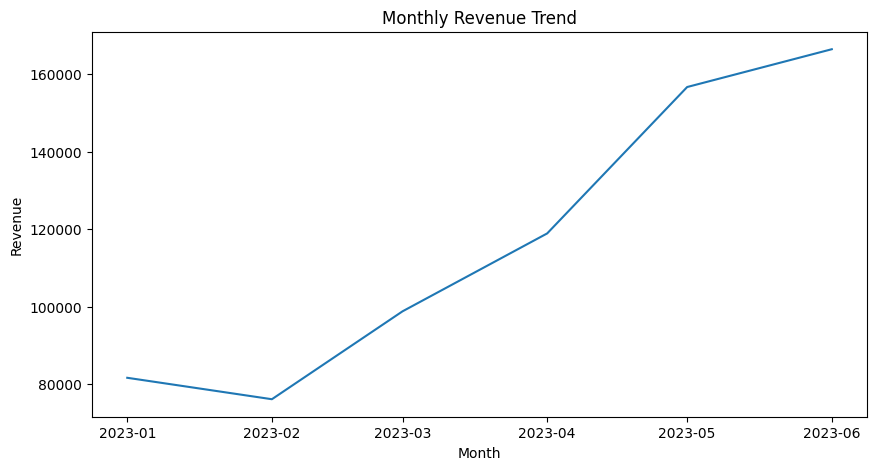

In [10]:

df['date'] = df['transaction_date'].dt.date
daily = df.groupby('date', as_index=False)['total_sales'].sum().rename(columns={'total_sales':'daily_revenue'})
df['year_month'] = df['transaction_date'].dt.to_period('M').astype(str)
monthly = df.groupby('year_month', as_index=False)['total_sales'].sum().rename(columns={'total_sales':'monthly_revenue'})

plt.figure(figsize=(10,5))
plt.plot(pd.to_datetime(monthly['year_month']), monthly['monthly_revenue'])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


## 6. Forecasting

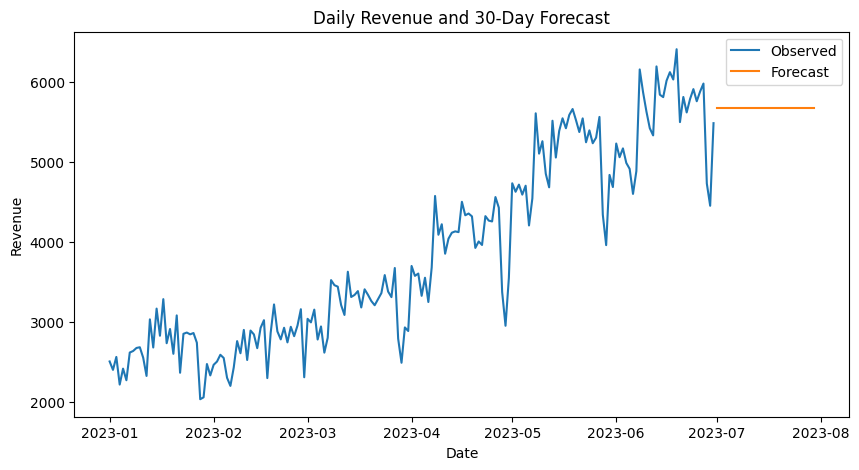

In [11]:

forecast_series = None
daily_ts = daily.set_index('date')['daily_revenue'].astype(float)
daily_ts = daily_ts.asfreq('D').fillna(0.0)

if HAS_HW and len(daily_ts) >= 60:
    model = ExponentialSmoothing(daily_ts, trend='add', seasonal='add', seasonal_periods=7)
    hw_fit = model.fit(optimized=True)
    forecast_series = hw_fit.forecast(30)
else:
    window = min(14, max(3, len(daily_ts)//12))
    rolling = daily_ts.rolling(window=window, min_periods=1).mean()
    last_val = rolling.iloc[-1] if len(rolling) else 0.0
    forecast_series = pd.Series([last_val]*30, index=pd.date_range(daily_ts.index[-1] + pd.Timedelta(days=1), periods=30))

plt.figure(figsize=(10,5))
plt.plot(daily_ts.index, daily_ts.values, label="Observed")
plt.plot(forecast_series.index, forecast_series.values, label="Forecast")
plt.title("Daily Revenue and 30-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.show()


## 7. Profitability Analysis

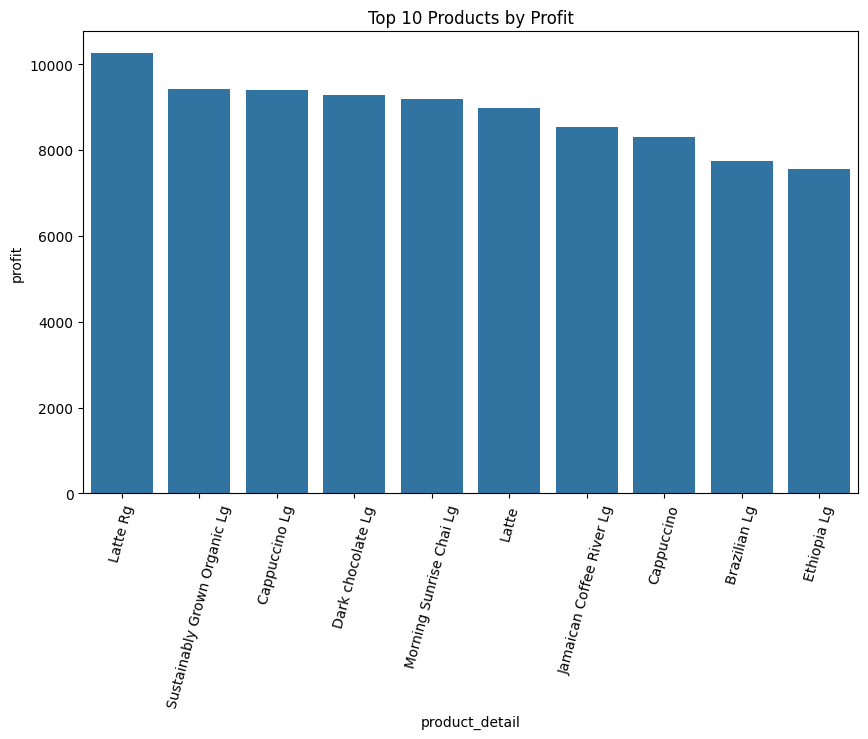

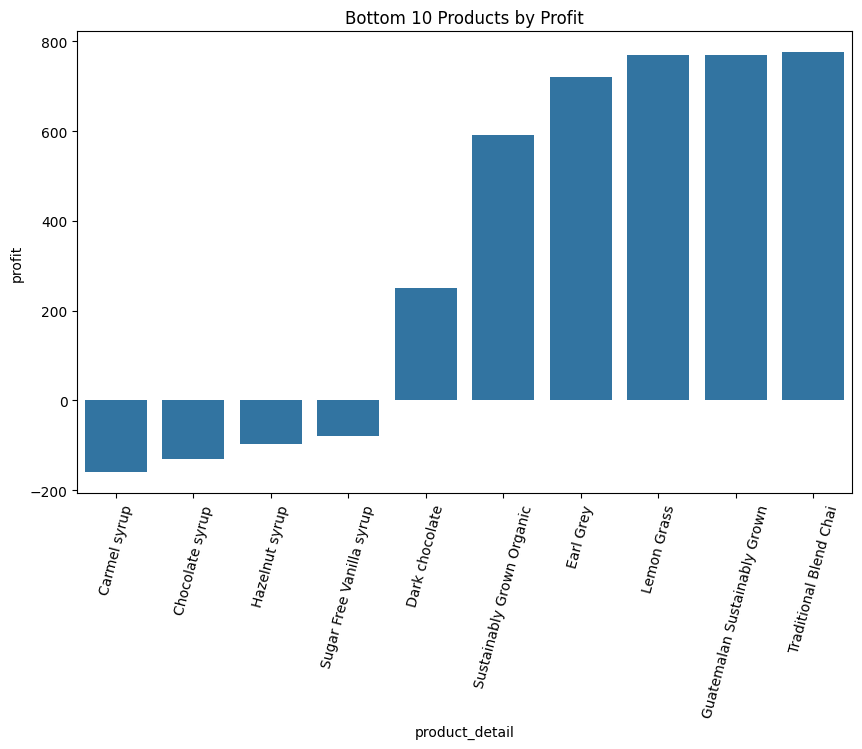

In [12]:

top10_profit = by_product.sort_values('profit', ascending=False).head(10)
bottom10_profit = by_product.sort_values('profit').head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='product_detail', y='profit', data=top10_profit)
plt.title("Top 10 Products by Profit")
plt.xticks(rotation=75)
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x='product_detail', y='profit', data=bottom10_profit)
plt.title("Bottom 10 Products by Profit")
plt.xticks(rotation=75)
plt.show()


## 8. Save Outputs

In [13]:

df.to_csv("Coffee_Shop_Sales_Cleaned.csv", index=False)
by_product.to_csv("Summary_By_Product.csv", index=False)
by_category.to_csv("Summary_By_Category.csv", index=False)
daily.to_csv("Summary_Daily.csv", index=False)
monthly.to_csv("Summary_Monthly.csv", index=False)
print("Outputs saved as CSV files.")


Outputs saved as CSV files.
